# 풀잎스쿨 데싸반 : 캐글 입문을 위한 타이타닉 예제를 사용해서 인사이트를 얻어봐요



In [848]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [849]:
data=pd.read_csv('/Users/wonseokjung/Dropbox/19_kaggle/titanic/titanic-machine-learning-from-disaster/train.csv')

In [850]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [851]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [852]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

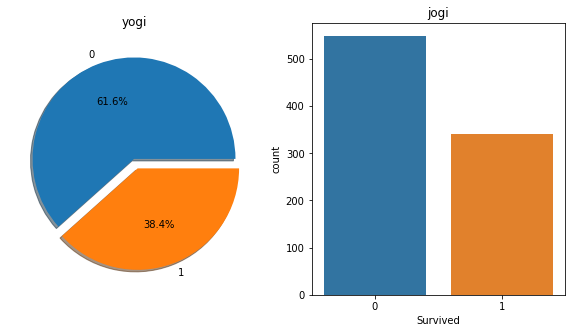

In [780]:
f,ax =plt.subplots(1,2,figsize = (10,5)) # 

data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)

ax[0].set_title('yogi')
ax[0].set_ylabel('')
sns.countplot('Survived',data=data, ax=ax[1])

ax[1].set_title('jogi')
plt.show()

위의 표를 보면 많은 사람들이 사고가 난 뒤에 살아남지 못했다는 것을 알 수 있다. 

총 891명의 승객 중에서 38.4%인 350명 정도만 살아남았다. 

데이터를 통해 어떤 슬객이 살아남지 못했는지 인사이트를 구해야 한다. 

데이터의 다른 feature를 통하여 survival rate를 체크할 것임 

여기서 feature는 Sex, prot of Embarcation, age 등임 


##  특징들을 분석

In [781]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [782]:
data.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [783]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [784]:
pd.crosstab(data.Sex, data.Survived, margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


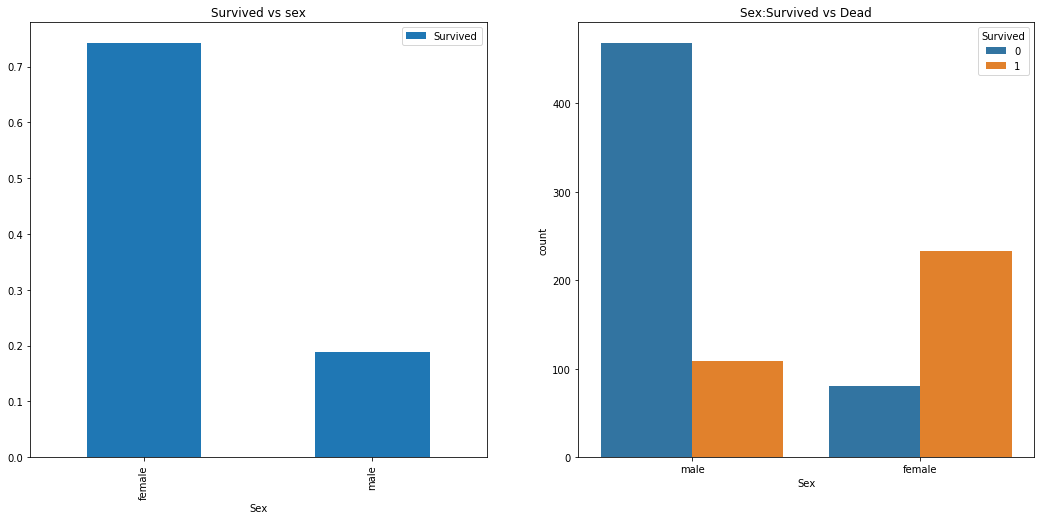

In [785]:
f,ax = plt.subplots(1,2,figsize=(18,8))
data[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs sex')
sns.countplot('Sex', hue='Survived',data=data, ax=ax[1])
ax[1].set_title('Sex:Survived vs Dead')
plt.show()

## Pclass

In [786]:
pd.crosstab(data.Pclass, data.Survived, margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


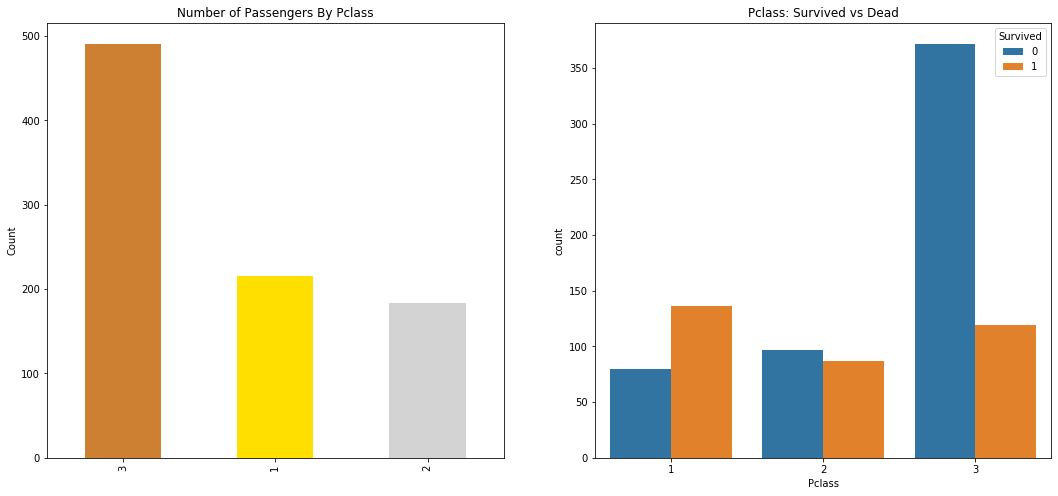

In [787]:
f,ax = plt.subplots(1,2,figsize=(18,8))
data['Pclass'].value_counts().plot.bar(color=['#CD7F32','#FFDF00','#D3D3D3'], ax=ax[0])
ax[0].set_title('Number of Passengers By Pclass')
ax[0].set_ylabel('Count')

sns.countplot('Pclass',hue='Survived',data=data, ax=ax[1])
ax[1].set_title('Pclass: Survived vs Dead')
plt.show()

In [788]:
# % 계산 

print("1등석 생존확률",136/216* 100)

print("2등석 생존확률",87/184 * 100 )

print("3등석 생존확률", 119/491 * 100)

#이것을 보면 pclass 와 생존확률의 상관관계가 있는것을 알 수 있다. 

1등석 생존확률 62.96296296296296
2등석 생존확률 47.28260869565217
3등석 생존확률 24.236252545824847


In [789]:
pd.crosstab([data.Sex,data.Survived], data.Pclass,margins=True).style.background_gradient(cmap='summer_r')

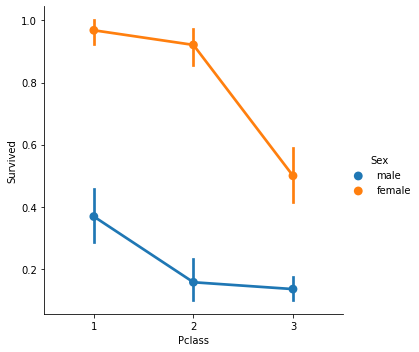

In [790]:
sns.factorplot('Pclass','Survived', hue='Sex',data=data)
plt.show()

## Age

In [791]:
print('가장 나이 많은 승객 :', data['Age'].max(),'살')
print('가장 어린 승객', data['Age'].min(),'살')
print('승객의 평균 나이', data['Age'].mean(),'살')

가장 나이 많은 승객 : 80.0 살
가장 어린 승객 0.42 살
승객의 평균 나이 29.69911764705882 살


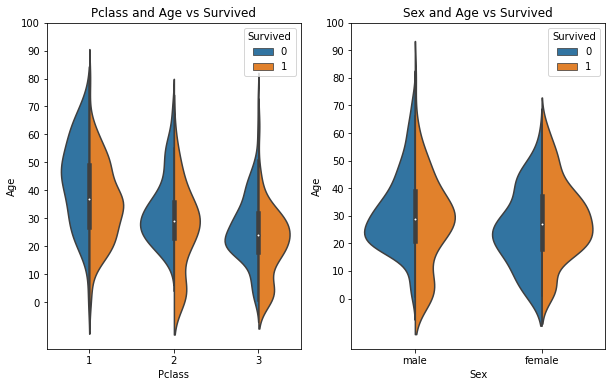

In [853]:
f,ax =plt.subplots(1,2,figsize=(10,6))
sns.violinplot('Pclass','Age', hue='Survived',data=data, split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))

sns.violinplot('Sex','Age',hue="Survived", data=data, split=True, ax=ax[1])

ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()



In [854]:
for i in data:
    print(data.Name.str.extract)

<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method StringMethods.extract of <pandas.core.strings.StringMethods object at 0x12f4950f0>>
<bound method String

In [855]:
data["Initial"]=0


for i in data:
    data["Initial"]=data.Name.str.extract('([A-Za-z]+)\.')
    



In [ ]:
data

('([A-Zaf-z]+)\.')를 사용함. 이 의미는 A-Z 또는 a-z 에서 . 앞에 오는 것을 찾음 

In [795]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


Intial과 Sex 체크

In [796]:
pd.crosstab(data.Initial, data.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [797]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr'],inplace=True)

In [798]:
pd.crosstab(data.Initial,data.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Master,Miss,Mr,Mrs,Other
Sex,,,,,
female,0,186,1,127,0
male,40,0,528,0,9


In [799]:
#Initial에 따른 나이

data.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

관찰

5살 이하의 아이들이 많이 살아남음 

가장 나이가 많았던 승객 (80살) 살아남음 

가장 많이 죽은 승객의 나이대는 30~40살 범위 


## Embarked

In [800]:
pd.crosstab([data.Embarked, data.Pclass],[data.Sex,data.Survived],margins=True).style.background_gradient(cmap='summer_r')

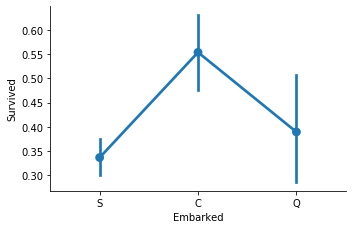

In [801]:
sns.factorplot('Embarked','Survived',data=data)

fig=plt.gcf()

fig.set_size_inches(5,3)
plt.show()

Port C에서 승선한 사람이 가장 높은 생존률을 보였으며 S에서 승선한 승객이 가장 낮은 생존률을 보인다.

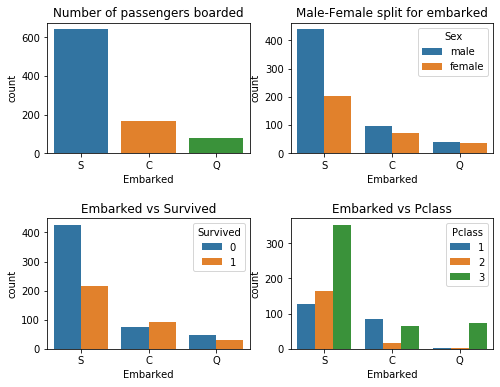

In [802]:
f,ax = plt.subplots(2,2, figsize= (8,6))

sns.countplot("Embarked",data=data, ax=ax[0,0])
ax[0,0].set_title("Number of passengers boarded")
sns.countplot('Embarked',hue='Sex',data=data, ax=ax[0,1])
ax[0,1].set_title('Male-Female split for embarked')
sns.countplot('Embarked',hue = 'Survived',data=data, ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')

sns.countplot('Embarked', hue ='Pclass', data=data, ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()


### 관찰 내용 

1.탑승 승객의 수는 S가 가장 많으며 Q가 가장 적다. 

2.S에서 탑승한 승객의 생존률이 가장 낮으며 C에서 탑승한 승객의 생존률이 가장 높음 

3.S는 3등급 탑승객이 가장 많은반면 C는 1등급 탑승객이 가장 많음 


1,3번을 보며 -> S에서 탑승한 승객의 생존률이 C에서 탑승한 승객의 생존률보다 더 높은 이유는 좌석등급이 원인이 될수 있지 않을까? 




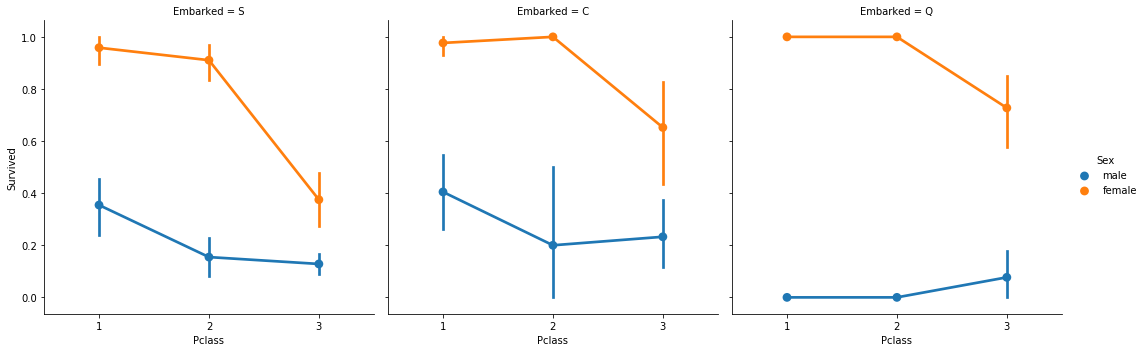

In [803]:
sns.factorplot('Pclass','Survived',hue = 'Sex', col = 'Embarked', data= data)
plt.show()

## SibSp

In [804]:
pd.crosstab(data.SibSp, data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


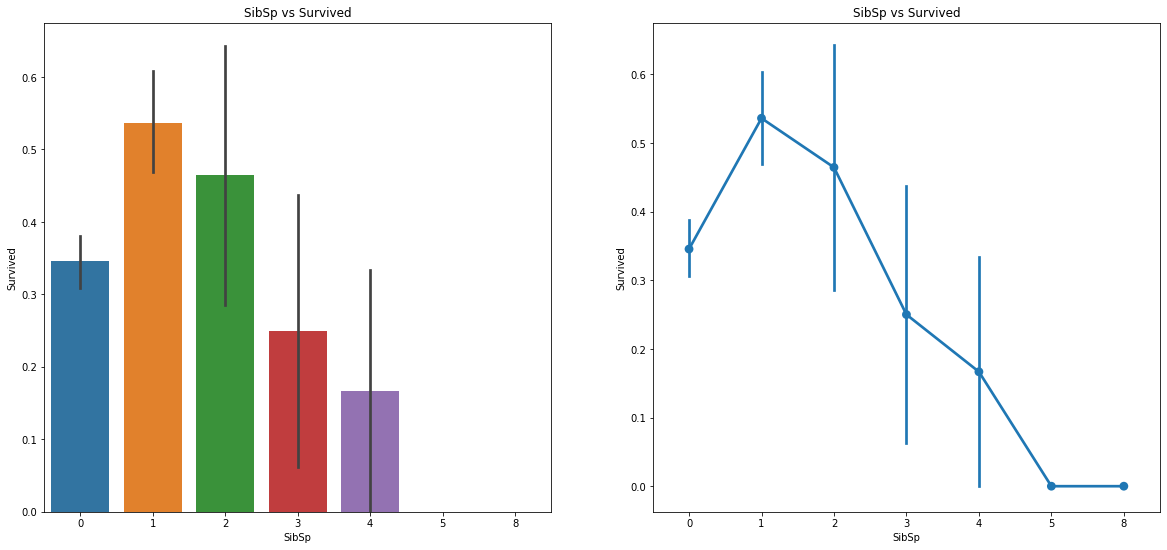

In [805]:

f,ax= plt.subplots(1,2, figsize = (20,9))

sns.barplot('SibSp','Survived',data=data,ax=ax[0])
ax[0].set_title('SibSp vs Survived')
sns.factorplot('SibSp','Survived',data = data, ax=ax[1])
ax[1].set_title('SibSp vs Survived')

plt.close(2)

plt.show()




In [806]:
pd.crosstab(data.SibSp, data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


###  관찰
1. 같이 탑승한 sibling이 없다면 35%의 생존률을 보임
2. Sibling이 많으면 많을수록 graph가 감소함 
3. 만약 내가 가족들과 많이 탑승했다면 나보다 가족들을 살리려고 노력헀을 것이다. 
4. Pclass의 영향도 있다. sibling의 숫자가 많은 (8) 경우는 모두 3 등급 좌석에 앉았다. 

## Parch

In [807]:
pd.crosstab(data.Parch, data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


## Fare

In [808]:
print('가장 높은 가격',data.Fare.max())
print('가장 낮은 가격', data['Fare'].min())
print('평균 가격',data.Fare.mean())

가장 높은 가격 512.3292
가장 낮은 가격 0.0
평균 가격 32.204207968574636


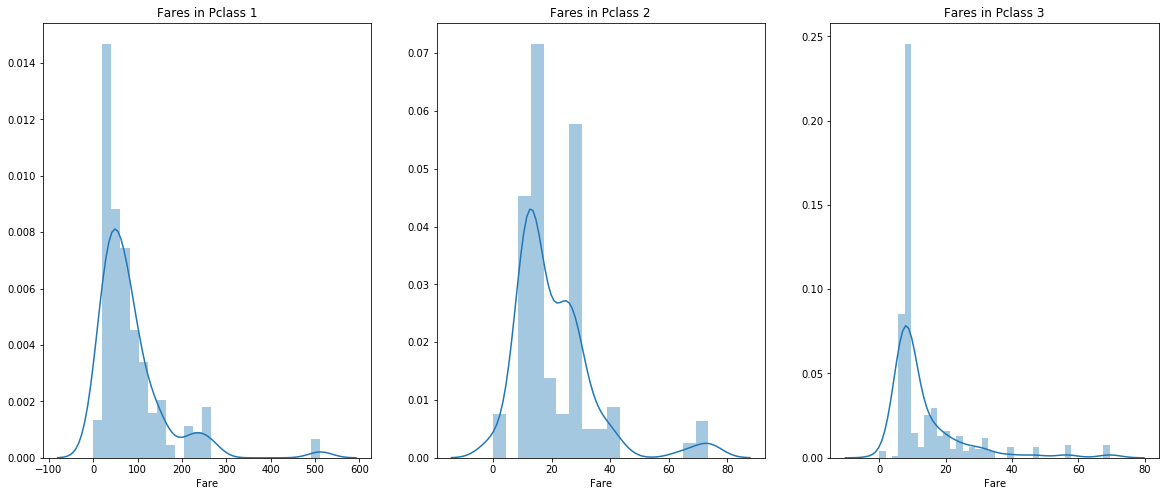

In [809]:
f,ax = plt.subplots(1,3, figsize = (20,8))
sns.distplot(data[data['Pclass']==1].Fare, ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(data[data['Pclass']==2].Fare, ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(data[data['Pclass']==3].Fare, ax=ax[2])
ax[2].set_title('Fares in Pclass 3')

plt.show()



## 모든 features에 의한 관찰 

1. Sex : 여성이 남자보다 생종률이 높다 
2. Pclass : 1등급 생존률이 가장 높으며 3등급에 앉은 승객의 생존률이 가장 낮다. 
3. Age : 5살 이하 아이들의 생존률이 높은반면 15~35살 사이의 승객들의 생존확률이 낮았다. 
4. Embarked : C의 생존률이 가장 높다


## 두번째 시간 :)  10월 21일 월요일

### 두번쨰 : Feature engineering

### feature engineering 이란 ? 


1. dataset의 모든 feature 가 중요하지는 않다. 

2. eliminate 되어야할 redundant features가 많을것이다. 

3. 또한 feature들을 관찰하며 새로운 feature를 더하거나 새롭게 얻을수도 있을 것이다. 




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [810]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [811]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Initial'],
      dtype='object')

In [812]:
for col in data.columns: 
    print(col)

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked
Initial


In [813]:
data[col]

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
       ...  
886    Other
887     Miss
888     Miss
889       Mr
890       Mr
Name: Initial, Length: 891, dtype: object

In [814]:
data['Age'].isnull().sum()

177

In [815]:
for col in data.columns:
    print("column:", col,data[col].isnull().sum())

column: PassengerId 0
column: Survived 0
column: Pclass 0
column: Name 0
column: Sex 0
column: Age 177
column: SibSp 0
column: Parch 0
column: Ticket 0
column: Fare 0
column: Cabin 687
column: Embarked 2
column: Initial 0


### Age의 null값이 177개나 있군요.. 이걸 어떻게 바꾸면 좋을까요? 

In [816]:
data['Initial']

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
       ...  
886    Other
887     Miss
888     Miss
889       Mr
890       Mr
Name: Initial, Length: 891, dtype: object

In [817]:
data["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

extract()를 사용하면 우리가 원하는 조건을 불러올 수 있습니다.
정규표현식 예제 :  https://www.fun-coding.org/DS&AL3-4.html 

str을 붙이게 되면 string으로 바꾸어주고, extract를 붙여주고 정규표현식을 넣어준다. 

대문자 A-Z  소문자 a-z 하나의 캐릭터가 이상이며 뒤에 .이 붙은 것 

In [818]:
data.Name.str.extract('([A-Za-z]+)\.')

,0
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [819]:
data.Name.str.extract('([A-Za-z]+)\.')

,0
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [820]:
data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')

In [821]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [822]:
data_test=pd.read_csv("https://www.dropbox.com/s/rv3u53qkhmp1s2e/test.csv?dl=1")

In [823]:
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [824]:
data_test['Initial']=data_test.Name.str.extract('([A-Za-z]+\.)')

In [825]:
pd.crosstab(data['Initial'], data['Sex']).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


다섯개로 그룹핑 작업을 해보겠습니다. 

<img src="https://www.dropbox.com/s/dugsq09cp98tehb/Screenshot%202019-10-21%2018.51.45.png?raw=1">

Capt :캡틴
Countess : 백작부인 혹은 여자백작
Jonkheer :  귀족 



In [826]:
data['Initial']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Initial, Length: 891, dtype: object

In [856]:
data['Initial'].replace(['Master','Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don', 'Dona'],
                        ['Mr','Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr', 'Mr'],inplace=True)

In [857]:
data['Initial']

0         Mr
1        Mrs
2       Miss
3        Mrs
4         Mr
       ...  
886    Other
887     Miss
888     Miss
889       Mr
890       Mr
Name: Initial, Length: 891, dtype: object

In [858]:
data_test['Initial'].replace(['Master','Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don', 'Dona'],
                        ['Mr','Miss','Miss','Miss','Mr','Mr','Mrs','Mrs','Other','Other','Other','Mr','Mr','Mr', 'Mr'],inplace=True)

In [830]:
data_test['Initial']

0          Mr.
1         Mrs.
2          Mr.
3          Mr.
4         Mrs.
        ...   
413        Mr.
414      Dona.
415        Mr.
416        Mr.
417    Master.
Name: Initial, Length: 418, dtype: object

In [831]:
data_all=pd.concat([data,data_test])

In [832]:
data_all

,Age,Cabin,Embarked,Fare,Initial,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,Mr,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171
1,38.0,C85,C,71.2833,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599
2,26.0,NaN,S,7.9250,Miss,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282
3,35.0,C123,S,53.1000,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803
4,35.0,NaN,S,8.0500,Mr,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,NaN,NaN,S,8.0500,Mr.,"Spector, Mr. Woolf",0,1305,3,male,0,NaN,A.5. 3236
414,39.0,C105,C,108.9000,Dona.,"Oliva y Ocana, Dona. Fermina",0,1306,1,female,0,NaN,PC 17758
415,38.5,NaN,S,7.2500,Mr.,"Saether, Mr. Simon Sivertsen",0,1307,3,male,0,NaN,SOTON/O.Q. 3101262
416,NaN,NaN,S,8.0500,Mr.,"Ware, Mr. Frederick",0,1308,3,male,0,NaN,359309


In [859]:
data.groupby('Initial').mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Initial,,,,,,,
Miss,411.741935,0.704301,2.284946,21.860000,0.698925,0.537634,43.937188
Mr,453.005272,0.191564,2.398946,30.461056,0.434095,0.237258,25.626170
Mrs,456.393701,0.795276,1.984252,35.981818,0.692913,0.818898,45.420603
Other,564.444444,0.111111,1.666667,45.888889,0.111111,0.111111,19.102778


In [834]:
data.loc[1:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,Miss


In [835]:
data.loc[data['Survived']==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,Miss
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,Mrs
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,Mrs
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss


In [861]:
data.loc[(data['Age'].isnull())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,Mr
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C,Mrs
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,Mr
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q,Miss
...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,Mr
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S,Miss
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,Mr
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S,Mr


In [860]:
data.loc[(data['Age'].isnull())&(data['Initial']=='Mr')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S,Mr
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C,Mr
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S,Mr
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,840,1,1,"Marechal, Mr. Pierre",male,NaN,0,0,11774,29.7000,C47,C,Mr
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S,Mr
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C,Mr
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,Mr


In [836]:
data.loc[(data['Age'].isnull())&(data['Initial']=='Mr'),'Age']

5     NaN
17    NaN
26    NaN
29    NaN
36    NaN
       ..
839   NaN
846   NaN
859   NaN
868   NaN
878   NaN
Name: Age, Length: 120, dtype: float64

In [837]:
data.loc[(data['Age'].isnull())&(data['Initial']=='Mr'),'Age']= 33

다 없어짐


In [838]:
data.loc[(data['Initial']=='Mr'),'Age']

0      22.0
4      35.0
5      33.0
6      54.0
12     20.0
       ... 
881    33.0
883    28.0
884    25.0
889    26.0
890    32.0
Name: Age, Length: 529, dtype: float64

In [839]:
#트레인 데이터 모든 

data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age'] = 33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age'] = 36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age'] = 5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age'] = 22
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age'] = 46


#테스트에도 똑같이 해줘야한다.
data_test.loc[(data_test.Age.isnull())&(data_test.Initial=='Mr'),'Age'] = 33
data_test.loc[(data_test.Age.isnull())&(data_test.Initial=='Mrs'),'Age'] = 36
data_test.loc[(data_test.Age.isnull())&(data_test.Initial=='Master'),'Age'] = 5
data_test.loc[(data_test.Age.isnull())&(data_test.Initial=='Miss'),'Age'] = 22
data_test.loc[(data_test.Age.isnull())&(data_test.Initial=='Other'),'Age'] = 46

In [840]:
data['Age'].isnull().sum()

0

In [841]:
data_test['Age'].isnull().sum()

86

### Embarked

In [844]:
print('Embarked has ', sum(data['Embarked'].isnull()), ' Null values')

Embarked has  2  Null values


In [845]:
data['Embarked'].fillna('S',inplace=True)

In [846]:
print('Embarked has ', sum(data['Embarked'].isnull()), ' Null values')

Embarked has  0  Null values


## Correlation B/W Features

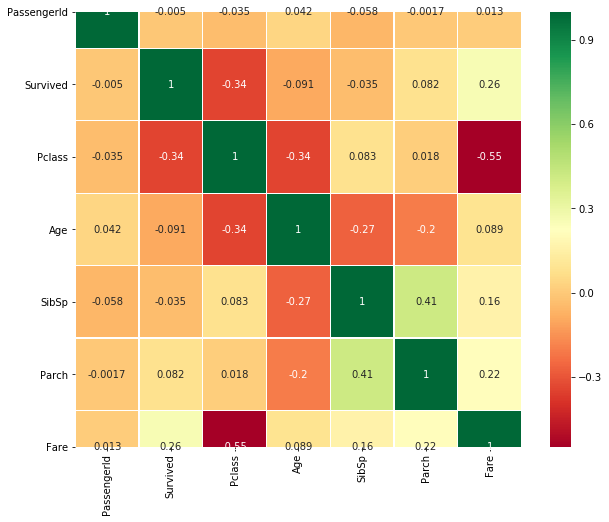

In [842]:
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', linewidths=0.2) #여기서 data.corr은 correlation matrix를 뚯한다.

fig = plt.gcf()
fig.set_size_inches(10,8)
plt.show()


## Interpreting the heatmap

Correlation 이란 ? 

1. Positive Correlation : feature A의 상승으로 인해 feature B도 상승한다. 값이 1안 경우를 완벽한 positive correlation이라고 한다. 
2. Negative Correlation : feature A의 상승으로 feature B 가 하락한다. 값이 -1일 경우가 완벽한 negative correlation

두 feature의 correlate가 높다면 두개의 feature가 포함하고 있는 정보가 높다고 하며 information의 variance가 낮다고 한다. 

두개의 feture가 거의 같은 information을 갖고 있다고 할 경우를 multiColinearity라고 한다. 

이와같이 multicolinearity인 경우 하나의 feature를 redundant로 보고 하나의 feature를 제거해주는 방법을 사용할 수도 있다. 
이렇게 할 경우 학습 시간을 줄일수 있다.

위의 heatmap을 보면, SibSp와 Parch가 가장 높은 correlation을 보인다. 
